# Week 2: Estimation (Individual)

In Week 1, you explored the system and developed a shared simulation framework.  
In Week 2, you will begin working individually to extract useful structure from the observed data.

## Objective

The internal state of the system is not directly observable. Your task is to design an approach that uses the available observations (and inputs) to construct a useful representation of the system.

There is **no single correct method**. You are expected to logically propose, clearly justify, and meaningfully evaluate your own approach.

## What does “estimation” mean here?

Depending on your design choices, your method need to aim to:

- identify patterns or structure in the observations,
- predict future observations,
- reconstruct hidden variables,
- compress the data into a lower-dimensional representation,
- extract features that can later be used for control.

## Tasks

You should:

1. **Define your objective**  
   Decide what you are trying to estimate and why it is useful.

2. **Design an approach**  
   Propose one or more methods based on your understanding of the system. Where possible, explore different approaches rather than relying on a single method, and compare their performance. Select the approach you consider most effective and justify your choice. Clearly state any assumptions you make.

3. **Implement your method**  
   Build on the Week 1 codebase. Test it on at least one simulation from Week 1. Your implementation does not need to be perfect, but it should be coherent and testable.

4. **Evaluate performance**  
   Use plots and quantitative measures to assess your method. Consider:
   - sensitivity to noise,
   - stability over time,
   - generalisation across different input patterns.

5. **Reflect on limitations**  
   Identify what your method does not capture and what could be improved.

## Guidance
- You may use both observations \(y(t)\) and inputs \(u(t)\). But inputs are not 100% reliable.
- You may use past data (history) if helpful.
- Simpler methods are acceptable if they are clearly justified and well analysed.
- A partially successful but well-explained approach is better than a complex but poorly understood one.

## Week 2 deliverable
**Deliverable:** Interim Report + code.
**Marks:** 20 individual marks.
**Due:** Friday 29 May at 9:00am BST. 

## Testing and evaluating your interface
On **Friday 29 May between 11am and 1pm**, the demonstrator will test your estimator to ensure that your interface meets the required specifications.  

This session is **compulsory** and important for your understanding and progression to the next stage of the project.

## Interim report guidance
Your interim report should be concise and focused, approximately **4 pages** in length, and must not exceed **5 pages total**, including figures and any appendix material.

The report should include:

- A brief description of the system and the simulations you have run,
- A summary of your Week 1 exploration,
- A clear description of your estimation approach,
- Initial results, with figures, demonstrating depth of analysis rather than broad but superficial coverage,
- A discussion of limitations and planned next steps.

The goal of the interim report is to demonstrate your understanding so far and to receive feedback ahead of the final stage.

## Connection to later work
Your estimation approach will form the basis for your control strategy in Week 3.  
Think ahead about how your representation could be used to influence the system.

## Estimation interface

To make testing and evaluation consistent across students, all estimation methods must follow the interface below.

You are free to implement any estimation strategy internally, provided that your function:
- accepts observations as input,
- returns estimated latent states and estimated inputs,
- and preserves the required function signature.

### Important:
- Do not change the function signature of `estimate_latent_and_input`. The demonstrator will call this function to evaluate your solution during the Week 2 evaluation session.
- You may implement any logic inside the function, but it must return:
   1. estimated latent states with shape (Timepoints, LatentDim)
   2. estimated inputs with shape (Timepoints, InputDim)
- If your method uses additional hyperparameters, use partial functions or wrapper functions to fix them before submission. You will not have the opportunity to adjust hyperparameters during the test. Automatic parameter tuning is welcome.


EM reached max iterations (100) without full convergence.
Processed Trial 0:
Latents Shape: (60, 3)
Inputs Shape: (60, 1)


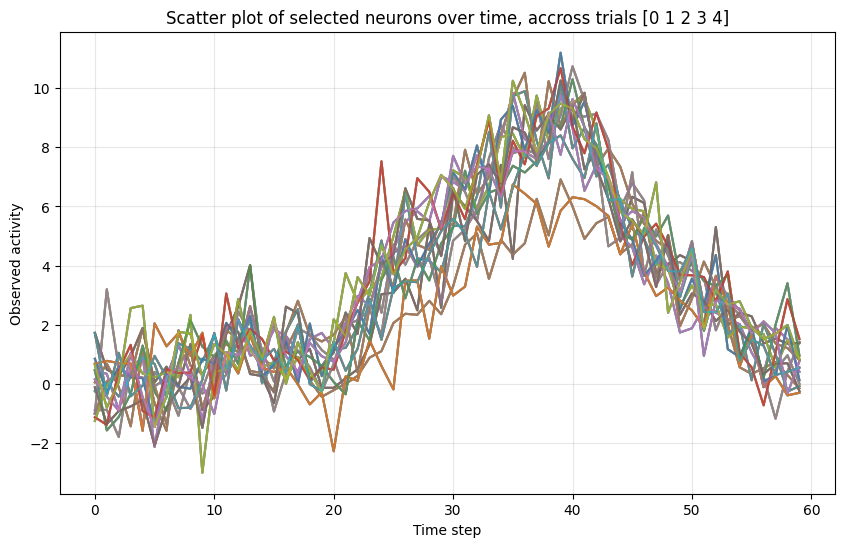

[[ 0.28284064  0.12341505 -0.17109274]
 [ 0.23177271  0.45608779 -0.06507814]
 [ 0.25487637 -0.39284858  0.02441317]
 [ 0.17266727  0.40484473  0.12748057]
 [ 0.26957907 -0.1167593  -0.38851425]
 [ 0.2527362  -0.02696475 -0.11338971]
 [ 0.27181002 -0.06455841  0.10719207]
 [ 0.17881614  0.32093177  0.12497279]
 [ 0.24311634  0.20977786  0.43860012]
 [ 0.26912513 -0.24391684  0.56292555]
 [ 0.2487558   0.20785363 -0.21947949]
 [ 0.27537892 -0.23471087 -0.23680772]
 [ 0.26123909 -0.19209527 -0.02214834]
 [ 0.27237854 -0.04156015 -0.2986091 ]
 [ 0.25880437 -0.24932625  0.23458252]
 [ 0.22458797  0.18550648  0.02333759]]


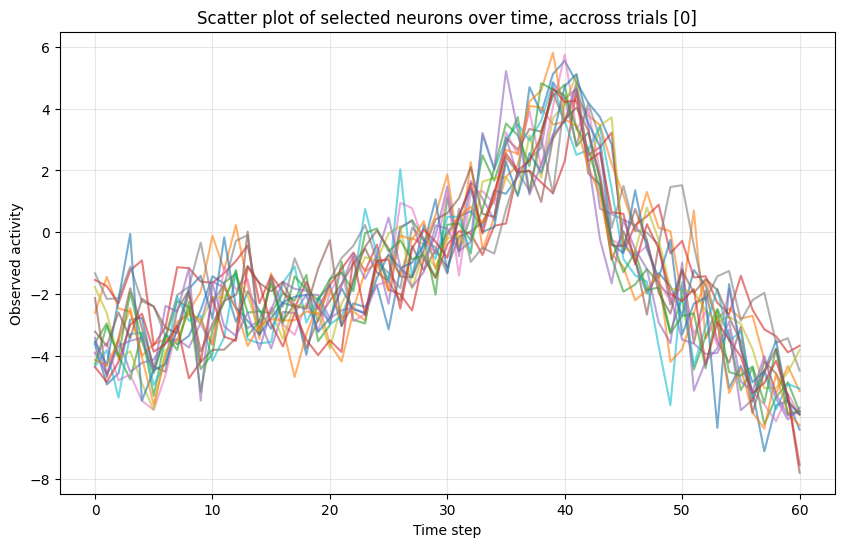

Plotting Latent States:


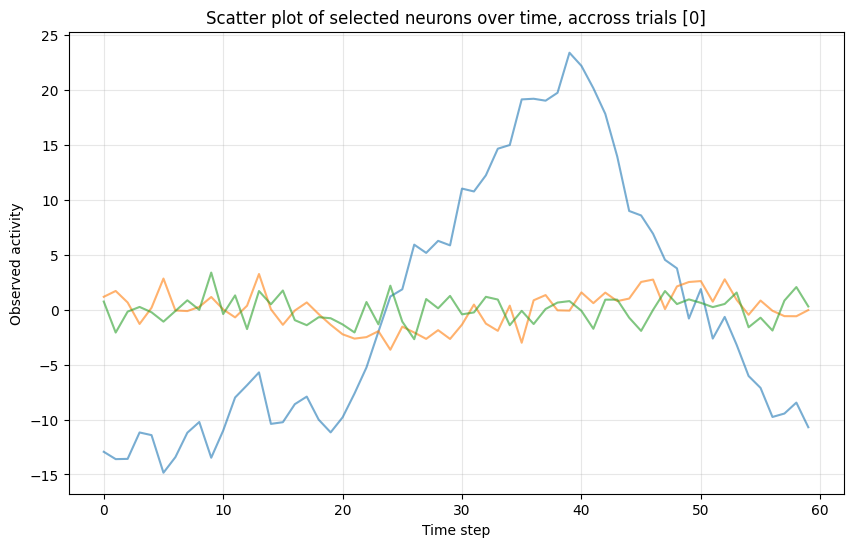

Plotting Inputs:


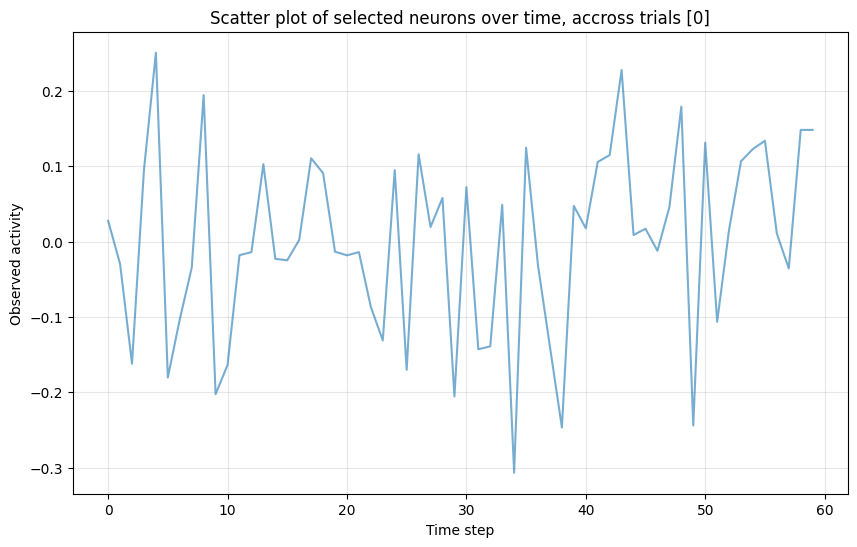

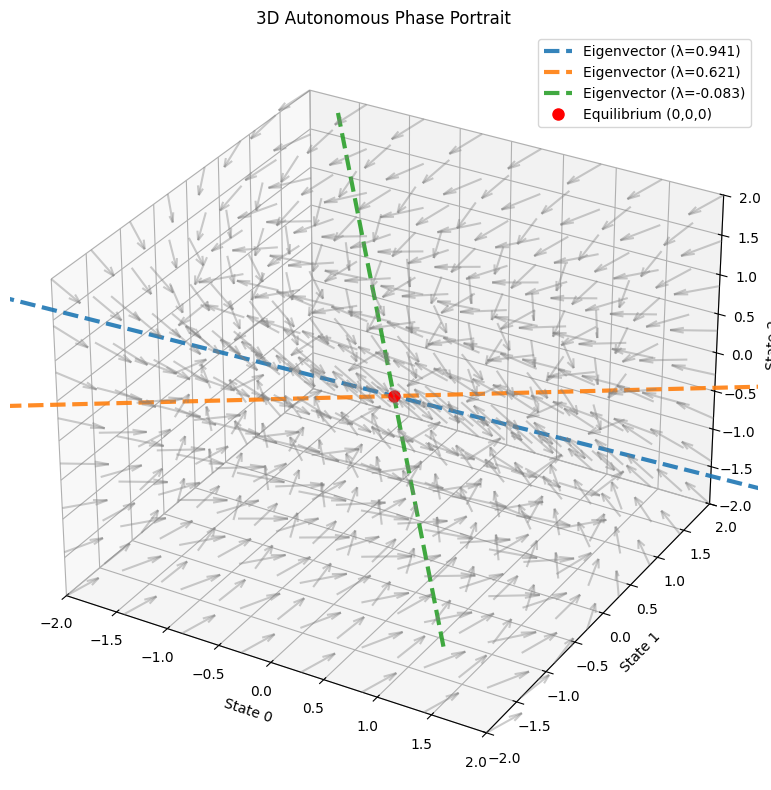

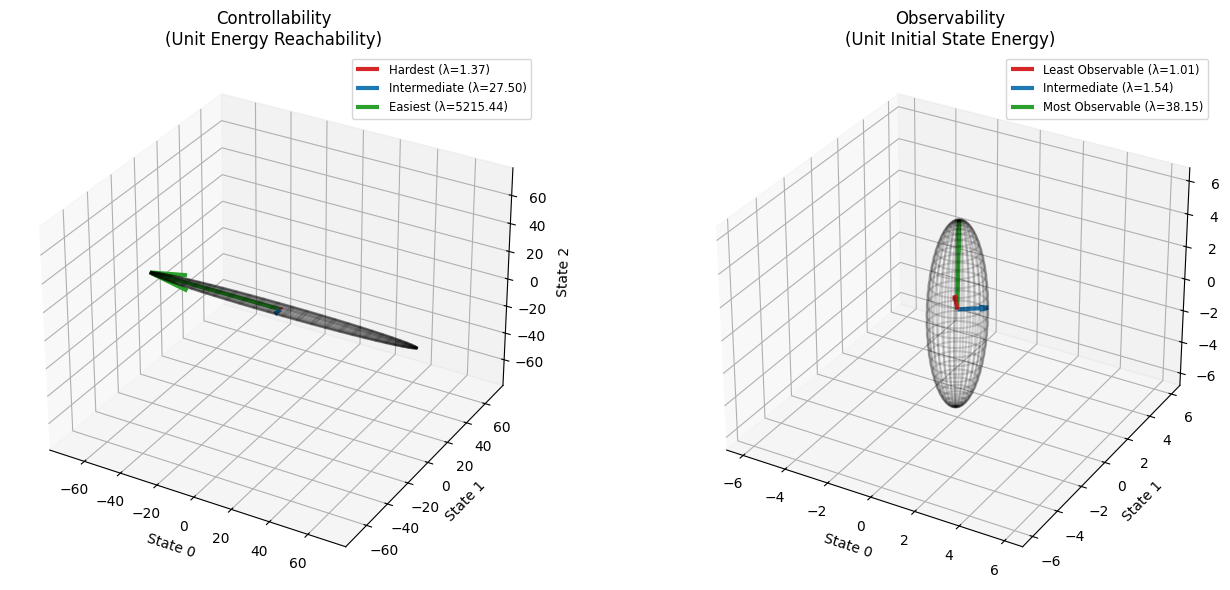

In [3]:
from typing import Tuple
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import lstsq
from LDSParams import LDSParams
from Illustrator import Illustrator
from Simulator import Simulator
rng = np.random.default_rng()
# --- 1. System ID & Estimation Engine ---
def _estimate_all_parameters(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Performs System Identification to learn the physics (LDSParams) 
    and reconstructs the states/inputs.
    """
    T, N = observation.shape
    
    # STEP 1: INITIAL DECOMPOSITION (PCA)
    # We find a subspace that accounts for both internal state and external input
    pca = PCA(n_components=LatentDim + InputDim)
    z = pca.fit_transform(observation)
    
    # Initial split: Assume first components are latents (internal) 
    # and subsequent components are input-driven
    x_init = z[:, :LatentDim]
    u_init = z[:, LatentDim:]
    
    # STEP 2: LEARN DYNAMICS (System ID)
    # Solve x_{t+1} = A*x_t + B*u_t using Least Squares
    predictors = np.hstack([x_init[:-1], u_init[:-1]]) # (T-1, Latent+Input)
    targets = x_init[1:]                               # (T-1, Latent)
    
    sol, _, _, _ = lstsq(predictors, targets)
    A = sol[:LatentDim, :].T
    B = sol[LatentDim:, :].T
    
    # STEP 3: LEARN EMISSIONS (Mapping to Neurons)
    # Solve y_t = C*x_t
    C_lstsq, _, _, _ = lstsq(x_init, observation)
    C = C_lstsq.T # Transposed to match standard (Neurons, LatentDim) shape for np.matmul
    
    # STEP 4: ESTIMATE NOISE COVARIANCES
    # Q: Process noise (Dynamics error)
    x_pred = (A @ x_init[:-1].T + B @ u_init[:-1].T).T
    Q = np.atleast_2d(np.cov((x_init[1:] - x_pred).T))
    
    # R: Observation noise (Residual neural activity)
    # Note: We use C.T here to map back to the (Timepoints, Neurons) dimension
    R = np.atleast_2d(np.cov((observation - (x_init @ C.T)).T))
    
    # STEP 5: WRAP PARAMS
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=x_init[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    # Returning the initial PCA estimates as the current "best guess"
    # In a more advanced version, you'd run a Kalman Smoother here using 'lds'
    return x_init, u_init, lds

def _estimate_em_parameters(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    prior_lambda: float = 1.0,  # Gaussian Prior strength (Ridge penalty)
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System Identification.
    1. SVD/PCA to lock in Latent States (X) and Emissions (C).
    2. EM loop with Gaussian prior to find A, B, and unobserved Inputs (U).
    """
    T, N = observation.shape
    
    # --- PHASE 1: SUBSPACE EMISSIONS ---
    # Stack Y and perform SVD (via PCA) to decompose into States and C matrix
    pca = PCA(n_components=LatentDim)
    X = pca.fit_transform(observation)  # Shape: (T, LatentDim)
    C = pca.components_.T               # Shape: (N, LatentDim)
    
    # --- PHASE 2: EM INITIALIZATION ---
    # We use x_t to predict x_next
    x_t = X[:-1]
    x_next = X[1:]
    
    # Initialize A using simple least squares (assuming U=0 initially)
    A_lstsq, _, _, _ = lstsq(x_t, x_next)
    A = A_lstsq.T  # Shape: (LatentDim, LatentDim)
    
    # Initialize B randomly (small values) to break mathematical symmetry
    B = np.random.randn(LatentDim, InputDim) * 0.1
    
    # Initialize U
    U_est = np.zeros((T - 1, InputDim))
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # ---------------------------------------------------------
        # E-Step: Estimate U given A, B, X
        # Objective: min || x_next - A*x_t - B*u_t ||^2 + lambda * || u_t ||^2
        # ---------------------------------------------------------
        # 1. Calculate the residual that A could not explain
        E = x_next - (A @ x_t.T).T  # Shape: (T-1, LatentDim)
        
        # 2. Ridge Regression formula to find U (Applying the Gaussian Prior)
        # u_t = (B^T B + lambda * I)^-1 B^T e_t
        ridge_inv = np.linalg.inv(B.T @ B + prior_lambda * np.eye(InputDim))
        U_est = E @ B @ ridge_inv  # Shape: (T-1, InputDim)
        
        # ---------------------------------------------------------
        # M-Step: Update A and B given X and U_est
        # Objective: min || x_next - [A B] * [x_t; u_t] ||^2
        # ---------------------------------------------------------
        predictors = np.hstack([x_t, U_est])  # Shape: (T-1, LatentDim + InputDim)
        Theta, _, _, _ = lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        # ---------------------------------------------------------
        # Convergence Check
        # ---------------------------------------------------------
        delta = np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old)
        if delta < tol:
            print(f"EM converged at iteration {i+1}")
            break
    else:
        print(f"EM reached max iterations ({max_iter}) without full convergence.")
        
    # --- PHASE 4: ASSEMBLE SYSTEM ---
    # U_est is length T-1 (it drives the transitions). 
    # We pad it with a copy of the last input to align with the T-length observation array.
    U_full = np.vstack([U_est, U_est[-1:]])
    
    # Estimate Noise Covariances
    x_pred = (A @ x_t.T + B @ U_est.T).T
    Q = np.atleast_2d(np.cov((x_next - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X @ C.T)).T))
    
    # Wrap in LDS dataclass
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X, U_full, lds
# --- 2. Required Interface for Demonstrator ---
def estimate_latent_and_input(observation: np.ndarray, LatentDim: int, InputDim: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Standard interface. Calls the engine but hides the LDSParams from the demonstrator.
    """
    # Ensure observation is 2D (Timepoints, Neurons)
    if observation.ndim != 2:
        raise ValueError(f"Expected 2D observation, got {observation.shape}")
        
    latent_states, inputs, _ = _estimate_all_parameters(observation, LatentDim, InputDim)
    return latent_states, inputs

# --- 3. Execution on Batched Data ---
# Load data (Trials, Timepoints, Neurons)
data = np.load("ExampleDataset.npy") 

# If you want to process the FIRST trial:
trial_idx = 0
obs_trial = data[trial_idx] # This is (Timepoints, Neurons)

# Run the estimation
latents, inputs,lds = _estimate_all_parameters(obs_trial, LatentDim=4, InputDim=10)
latents, inputs,lds = _estimate_em_parameters(data[0],3,1)
def input(time,data):
    return inputs[time]
print(f"Processed Trial {trial_idx}:")
print(f"Latents Shape: {latents.shape}") # (Timepoints, 3)
print(f"Inputs Shape: {inputs.shape}")   # (Timepoints, 3)
ill = Illustrator(data)
ill.plot_general()
print(lds.C)
sim = Simulator([lds.A,lds.B,lds.C,lds.Q,lds.R])
fake_data = sim.generate_data(1,60,rng.multivariate_normal(lds.mu_0,lds.P_0),input)
fake_ill = Illustrator(fake_data)
fake_ill.plot_general()

# 1. Add a dummy "trial" dimension
latents_3d = np.expand_dims(latents, axis=0) # Shape becomes (1, Timepoints, LatentDim)
inputs_3d = np.expand_dims(inputs, axis=0)   # Shape becomes (1, Timepoints, InputDim)

# 2. Plot Latents
ill_latents = Illustrator(latents_3d)
print("Plotting Latent States:")
ill_latents.plot_general() 

# 3. Plot Inputs
ill_inputs = Illustrator(inputs_3d)
print("Plotting Inputs:")
ill_inputs.plot_general()
sim.plot_phase_portrait()
sim.plot_gramian_directions()